# 🏥 Novel Multimodal Risk Classifier — Care Companion AI
---
**Project:** Event-Aware Patient Risk Classification  
**Author:** [Your Name]  
**Version:** 1.0 · Major Project Review

---

## Overview

This notebook implements a **novel, multimodal, event-aware patient risk classifier** designed for the Care Companion AI system.

Unlike conventional vitals-only triage models, this classifier **fuses three distinct signal families**:

| Signal Family | Features |
|---|---|
| 🫀 **Physiological State** | Heart rate, blood pressure (systolic/diastolic), SpO₂, temperature |
| 🚨 **Event Burden** | Fall alerts, cough alerts, help alerts, manual SOS, prior high-risk alerts |
| 🚶 **Functional Context** | Activity level, daily steps, active minutes, bed-bound tendency |

### Key Novelty — Cross-Modal Interaction Features

The classifier does **not** simply concatenate these modalities. It explicitly models **interaction pressures** that arise when sensor events co-occur with physiological instability:

- `fall × hypotension` → fall with low blood pressure is far more dangerous than either alone  
- `cough × hypoxia` → cough combined with low SpO₂ suggests respiratory deterioration  
- `cough × fever` → infectious respiratory episode  
- `repeated help requests × prior high-risk history` → recurrent deterioration pattern  
- `SOS × fall` → simultaneous distress signals  

This makes the model suitable for a major-project review as a **custom multimodal fusion risk classifier** anchored in the project's existing alert subsystems (fall detection, cough detection, patient monitoring).

---

## Notebook Structure

1. 📦 **Imports & Configuration** — Seeds, paths, constants  
2. 🗃️ **Dataset Generation** — Synthetic multimodal training data  
3. 🔧 **Feature Engineering** — Interaction features, derived vitals, burden scores  
4. 🔍 **Exploratory Data Analysis** — Class distribution, correlation, feature distributions  
5. 🏋️ **Model Training** — Preprocessing pipeline + Soft-Voting ensemble  
6. 📊 **Evaluation & Visualisation** — Accuracy, classification report, confusion matrix, ROC/PR curves, feature importance  
7. 💾 **Model Serialisation** — Save trained model to disk  
8. 🩺 **Inference Demo** — Real-world sample prediction  


## 📦 1. Imports & Configuration

All dependencies, global constants, reproducibility seeds, and I/O paths are defined here.

In [1]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 1 — Imports & Configuration
# Purpose : Centralise all imports, global hyper-parameters, and path constants
#            so every downstream cell can be run in isolation without hunting
#            for stray configuration variables.
# ──────────────────────────────────────────────────────────────────────────────

from __future__ import annotations

import random
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, VotingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize

warnings.filterwarnings("ignore")  # suppress sklearn version warnings during review

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# ── Paths ─────────────────────────────────────────────────────────────────────
# Resolve root regardless of whether the kernel is launched from the repo root
# or from within the models/risk sub-directory.
PROJECT_ROOT = (
    Path.cwd().resolve().parents[1]
    if Path.cwd().name == "risk"
    else Path.cwd().resolve()
)
NOTEBOOK_DIR = PROJECT_ROOT / "models" / "risk"
NOTEBOOK_DIR.mkdir(parents=True, exist_ok=True)

CSV_PATH            = NOTEBOOK_DIR / "multimodal_risk_training_data.csv"
MODEL_PATH          = NOTEBOOK_DIR / "novel_multimodal_risk_classifier.joblib"
FEATURE_EXPORT_PATH = NOTEBOOK_DIR / "multimodal_risk_feature_sample.csv"

# ── Plot styling ──────────────────────────────────────────────────────────────
PALETTE = {"LOW": "#2ecc71", "MEDIUM": "#f39c12", "HIGH": "#e74c3c"}
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({"figure.dpi": 130, "figure.facecolor": "white"})

# ── Dataset hyper-parameters ──────────────────────────────────────────────────
N_ROWS   = 30_000   # synthetic rows when no real CSV is found
TEST_SIZE = 0.20    # 80 / 20 train–test split
CV_FOLDS  = 5       # k-fold cross-validation folds

print("✅ Imports complete.")
print(f"   Project root : {PROJECT_ROOT}")
print(f"   Notebook dir : {NOTEBOOK_DIR}")
print(f"   CSV path     : {CSV_PATH}")
print(f"   Model output : {MODEL_PATH}")


✅ Imports complete.
   Project root : G:\care-companion-ai-main
   Notebook dir : G:\care-companion-ai-main\models\risk
   CSV path     : G:\care-companion-ai-main\models\risk\multimodal_risk_training_data.csv
   Model output : G:\care-companion-ai-main\models\risk\novel_multimodal_risk_classifier.joblib


## 🗃️ 2. Synthetic Dataset Generation

When a real Supabase export is unavailable, the notebook generates a large (30 000-row) **synthetic multimodal dataset** that faithfully mirrors the project schema.

**Design decisions:**
- Vital-sign distributions are parameterised with realistic means and standard deviations drawn from clinical literature for an elderly home-care population.
- Alert counts follow Poisson distributions whose rate parameters are conditioned on physiological state (e.g., cough alert rate rises when SpO₂ < 95 or temperature ≥ 37.8 °C).
- The **risk label** is assigned by a deterministic scoring function that accumulates weighted evidence from all three modalities, plus interaction penalties — ensuring the label is self-consistent with the features and therefore learnable.

In [2]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 2 — Synthetic Dataset Generation
# Purpose : Produce a realistic, label-consistent training corpus that covers
#           the full physiological and event-burden space the deployed model
#           will encounter.
# ──────────────────────────────────────────────────────────────────────────────

# ── Vocabulary pools for free-text fields ────────────────────────────────────
HISTORY_TERMS = [
    "diabetes", "hypertension", "heart disease", "stroke", "copd", "asthma",
    "cancer", "history of falls", "kidney disease", "obesity", "smoker",
]

NOTE_TERMS = [
    "confusion", "fatigue", "dizziness", "poor appetite", "recent infection",
    "shortness of breath", "uses walker", "walking independently",
    "sleeping poorly", "chest discomfort",
]

ACTIVITY_LEVELS = ["bed_bound", "low", "moderate", "active"]


# ── Helper utilities ──────────────────────────────────────────────────────────

def choose_text(rng: np.random.Generator, values: list[str], max_count: int) -> str:
    """Sample up to *max_count* terms without replacement and join with commas."""
    count = int(rng.integers(0, max_count + 1))
    if count == 0:
        return ""
    return ", ".join(rng.choice(values, size=count, replace=False).tolist())


def poisson_clip(rng: np.random.Generator, lam: float, upper: int) -> int:
    """Draw a Poisson random variable, clamped to [0, upper]."""
    return int(np.clip(rng.poisson(lam=lam), 0, upper))


# ── Deterministic risk scorer ─────────────────────────────────────────────────

def score_multimodal_risk(row: dict) -> tuple[int, str]:
    """
    Compute a composite risk score (0-100) from all modalities and return
    the corresponding risk level (LOW / MEDIUM / HIGH).

    Scoring bands
    ─────────────
    ≥ 60  →  HIGH    (urgent clinical review warranted)
    30-59 →  MEDIUM  (close monitoring recommended)
    < 30  →  LOW     (routine follow-up)
    """
    score = 0

    # Unpack row for readability
    hr                  = row["heart_rate"]
    sbp                 = row["systolic_bp"]
    dbp                 = row["diastolic_bp"]
    spo2                = row["spo2"]
    temp                = row["temperature_c"]
    activity_level      = str(row["activity_level"]).lower()
    steps_24h           = row["steps_24h"]
    active_minutes_24h  = row["active_minutes_24h"]
    fall_alerts_24h     = row["fall_alerts_24h"]
    cough_alerts_24h    = row["cough_alerts_24h"]
    help_alerts_24h     = row["help_alerts_24h"]
    manual_sos_alerts_7d= row["manual_sos_alerts_7d"]
    high_risk_alerts_7d = row["high_risk_alerts_7d"]
    history             = str(row["history"]).lower()
    notes               = str(row["notes"]).lower()

    # ── Physiological vitals ──────────────────────────────────────────────────
    # Heart rate: severe bradycardia / tachycardia = +25, mild deviation = +12
    if hr < 50 or hr > 115:
        score += 25
    elif hr < 60 or hr > 100:
        score += 12

    # Systolic BP: hypertensive crisis or hypotension = +25, pre-hypertension = +12
    if sbp < 90 or sbp >= 160:
        score += 25
    elif sbp >= 140:
        score += 12

    # SpO₂: severe hypoxia ≤ 89% = +34, moderate = +16
    if spo2 < 90:
        score += 34
    elif spo2 < 94:
        score += 16

    # Temperature: fever ≥ 39 or hypothermia < 35 = +20, low-grade fever = +8
    if temp >= 39.0 or temp < 35.0:
        score += 20
    elif temp >= 38.0:
        score += 8

    # ── Functional / mobility context ─────────────────────────────────────────
    if activity_level == "bed_bound":
        score += 18
    elif activity_level == "low":
        score += 10

    if steps_24h < 500:
        score += 10
    elif steps_24h < 2000:
        score += 5

    if active_minutes_24h < 10:
        score += 6

    # ── Event burden ──────────────────────────────────────────────────────────
    score += 14 * fall_alerts_24h        # falls are high-weight events
    score += 8  * cough_alerts_24h
    score += 12 * help_alerts_24h
    score += 10 * manual_sos_alerts_7d
    score += 7  * high_risk_alerts_7d    # prior HIGH classification = recurrence risk

    # ── Clinical history keywords ─────────────────────────────────────────────
    if "history of falls" in history:
        score += 10
    if "copd" in history or "asthma" in history:
        score += 10
    if "heart disease" in history or "stroke" in history:
        score += 12
    if "diabetes" in history or "hypertension" in history:
        score += 8

    # ── Clinical notes keywords ───────────────────────────────────────────────
    if "confusion" in notes:
        score += 8
    if "shortness of breath" in notes:
        score += 10
    if "chest discomfort" in notes:
        score += 12

    # ── Derived haemodynamic indices ──────────────────────────────────────────
    shock_index    = hr / max(sbp, 1)   # SI ≥ 1.0 is a clinical red flag
    pulse_pressure = sbp - dbp          # < 25 mmHg suggests low cardiac output

    if shock_index >= 1.0:
        score += 14
    elif shock_index >= 0.8:
        score += 6

    if pulse_pressure < 25:
        score += 8

    # ── Novel cross-modal interaction penalties ───────────────────────────────
    # These capture synergistic risk that single-modality scores would miss.
    if fall_alerts_24h > 0 and sbp < 95:          # fall + hypotension
        score += 12
    if cough_alerts_24h > 0 and spo2 < 94:        # cough + hypoxia
        score += 12
    if cough_alerts_24h > 1 and temp >= 38.0:     # cough + fever → respiratory infection
        score += 10
    if help_alerts_24h > 0 and high_risk_alerts_7d > 0:  # help + recurrence
        score += 10
    if manual_sos_alerts_7d > 0 and fall_alerts_24h > 0: # SOS + fall
        score += 10

    score = int(min(score, 100))

    if score >= 60:
        return score, "HIGH"
    if score >= 30:
        return score, "MEDIUM"
    return score, "LOW"


# ── Dataset factory ───────────────────────────────────────────────────────────

def make_multimodal_dataset(rows: int = N_ROWS, seed: int = SEED) -> pd.DataFrame:
    """
    Generate *rows* synthetic patient records.

    Vital-sign distributions are conditioned on activity level and on each
    other to produce a realistic joint distribution.  Alert rates are
    Poisson-distributed with rate parameters that depend on physiological state.
    """
    rng     = np.random.default_rng(seed)
    records = []

    for _ in range(rows):
        # ── Activity level (sets mobility context) ────────────────────────────
        activity_level = rng.choice(ACTIVITY_LEVELS, p=[0.10, 0.28, 0.40, 0.22])
        low_mobility   = activity_level in {"bed_bound", "low"}

        # ── Physiological vitals ──────────────────────────────────────────────
        heart_rate   = int(np.clip(rng.normal(82, 18),   35,  170))
        systolic_bp  = int(np.clip(rng.normal(123, 23),  70,  220))
        diastolic_bp = int(np.clip(rng.normal(79, 14),   40,  140))
        spo2         = int(np.clip(rng.normal(95.5, 4.5), 72, 100))
        temperature_c = float(np.clip(rng.normal(36.9, 1.0), 33.0, 41.5).round(1))

        # ── Functional metrics ────────────────────────────────────────────────
        steps_24h          = int(np.clip(rng.normal(4500, 3200), 0, 22000))
        active_minutes_24h = int(np.clip(rng.normal(42, 28),     0,   240))

        # ── Alert rate parameters (conditioned on physiology) ─────────────────
        base_fall = 0.15 if low_mobility else 0.04
        base_cough = 0.22 if (spo2 < 95 or temperature_c >= 37.8) else 0.08
        base_help  = 0.08 if (spo2 < 93 or systolic_bp < 95) else 0.02
        base_sos   = 0.03 if (low_mobility and base_help > 0.04) else 0.005
        base_high  = 0.12 if (spo2 < 94 or temperature_c >= 38 or systolic_bp < 95) else 0.03

        fall_alerts_24h      = poisson_clip(rng, base_fall  * 3.0, 4)
        cough_alerts_24h     = poisson_clip(rng, base_cough * 4.0, 6)
        help_alerts_24h      = poisson_clip(rng, base_help  * 3.0, 4)
        manual_sos_alerts_7d = poisson_clip(rng, base_sos   * 6.0, 3)
        high_risk_alerts_7d  = poisson_clip(rng, base_high  * 6.0, 5)

        # ── Text fields ───────────────────────────────────────────────────────
        history = choose_text(rng, HISTORY_TERMS, 4)
        notes   = choose_text(rng, NOTE_TERMS, 3)

        record = {
            "heart_rate":           heart_rate,
            "systolic_bp":          systolic_bp,
            "diastolic_bp":         diastolic_bp,
            "spo2":                 spo2,
            "temperature_c":        temperature_c,
            "activity_level":       activity_level,
            "steps_24h":            steps_24h,
            "active_minutes_24h":   active_minutes_24h,
            "fall_alerts_24h":      fall_alerts_24h,
            "cough_alerts_24h":     cough_alerts_24h,
            "help_alerts_24h":      help_alerts_24h,
            "manual_sos_alerts_7d": manual_sos_alerts_7d,
            "high_risk_alerts_7d":  high_risk_alerts_7d,
            "history":              history,
            "notes":                notes,
        }
        risk_score, risk_level = score_multimodal_risk(record)
        record["risk_score"] = risk_score
        record["risk_level"] = risk_level
        records.append(record)

    return pd.DataFrame(records)


# ── Load or generate ──────────────────────────────────────────────────────────
if CSV_PATH.exists():
    df          = pd.read_csv(CSV_PATH)
    data_source = f"real CSV: {CSV_PATH.name}"
else:
    df          = make_multimodal_dataset(rows=N_ROWS)
    data_source = "synthetic multimodal event-aware dataset"

print(f"✅ Data loaded — source : {data_source}")
print(f"   Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print()
print("Class distribution:")
display(
    df["risk_level"]
    .value_counts()
    .rename_axis("risk_level")
    .reset_index(name="count")
    .assign(pct=lambda x: (x["count"] / x["count"].sum() * 100).round(2))
)
display(df.head(3))


✅ Data loaded — source : real CSV: multimodal_risk_training_data.csv
   Shape : 30,000 rows × 21 columns

Class distribution:


,risk_level,count,pct
0,HIGH,11975,39.92
1,LOW,9202,30.67
2,MEDIUM,8823,29.41


,patient_id,age_group,gender,profile,heart_rate,systolic_bp,diastolic_bp,spo2,temperature_c,activity_level,...,active_minutes_24h,fall_alerts_24h,cough_alerts_24h,help_alerts_24h,manual_sos_alerts_7d,high_risk_alerts_7d,history,notes,risk_score,risk_level
0,P00245,65-74,F,cardiac_patient,86.0,125.0,60.0,96.0,NaN,low,...,3.0,0,1,0,0,0,"history of falls, depression",recent infection,34,MEDIUM
1,P03955,75-84,M,healthy_senior,76.0,128.0,87.0,99.0,36.9,active,...,70.0,0,0,1,0,1,NaN,"poor appetite, walking independently",29,LOW
2,P02755,75-84,F,moderate_frailty,114.0,114.0,46.0,100.0,36.5,bed_bound,...,22.0,1,0,0,0,0,"osteoporosis, history of falls, atrial fibrill...","sleeping poorly, uses walker",95,HIGH


## 🔍 3. Exploratory Data Analysis

Before engineering features or training, we inspect the raw data to:
- Verify class balance
- Understand vital-sign distributions per risk class
- Identify correlations between alert counts and risk level

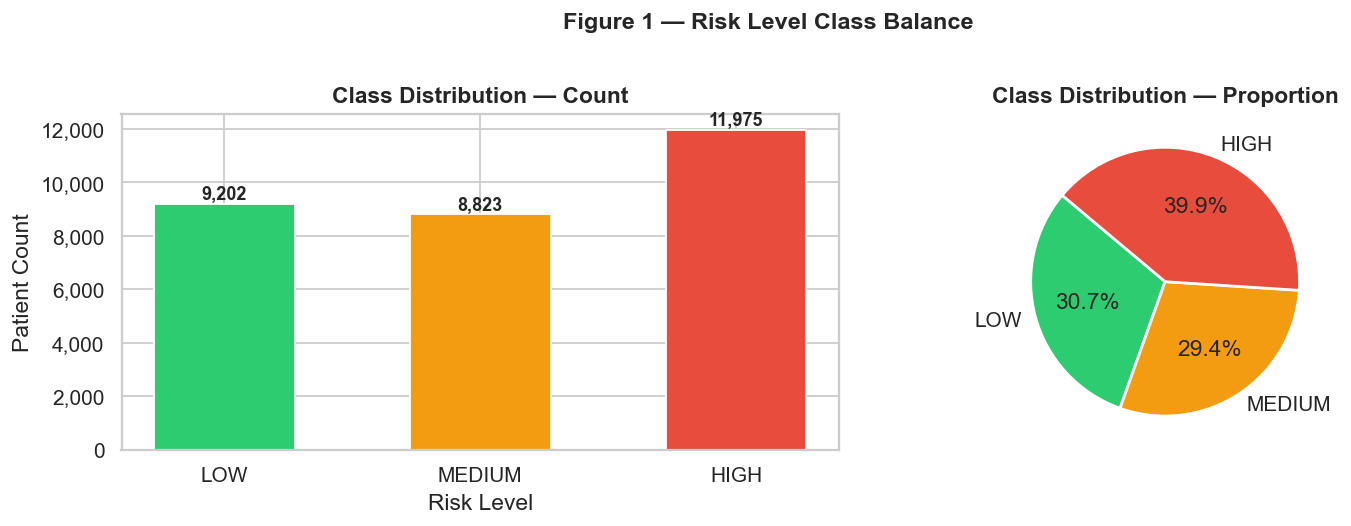

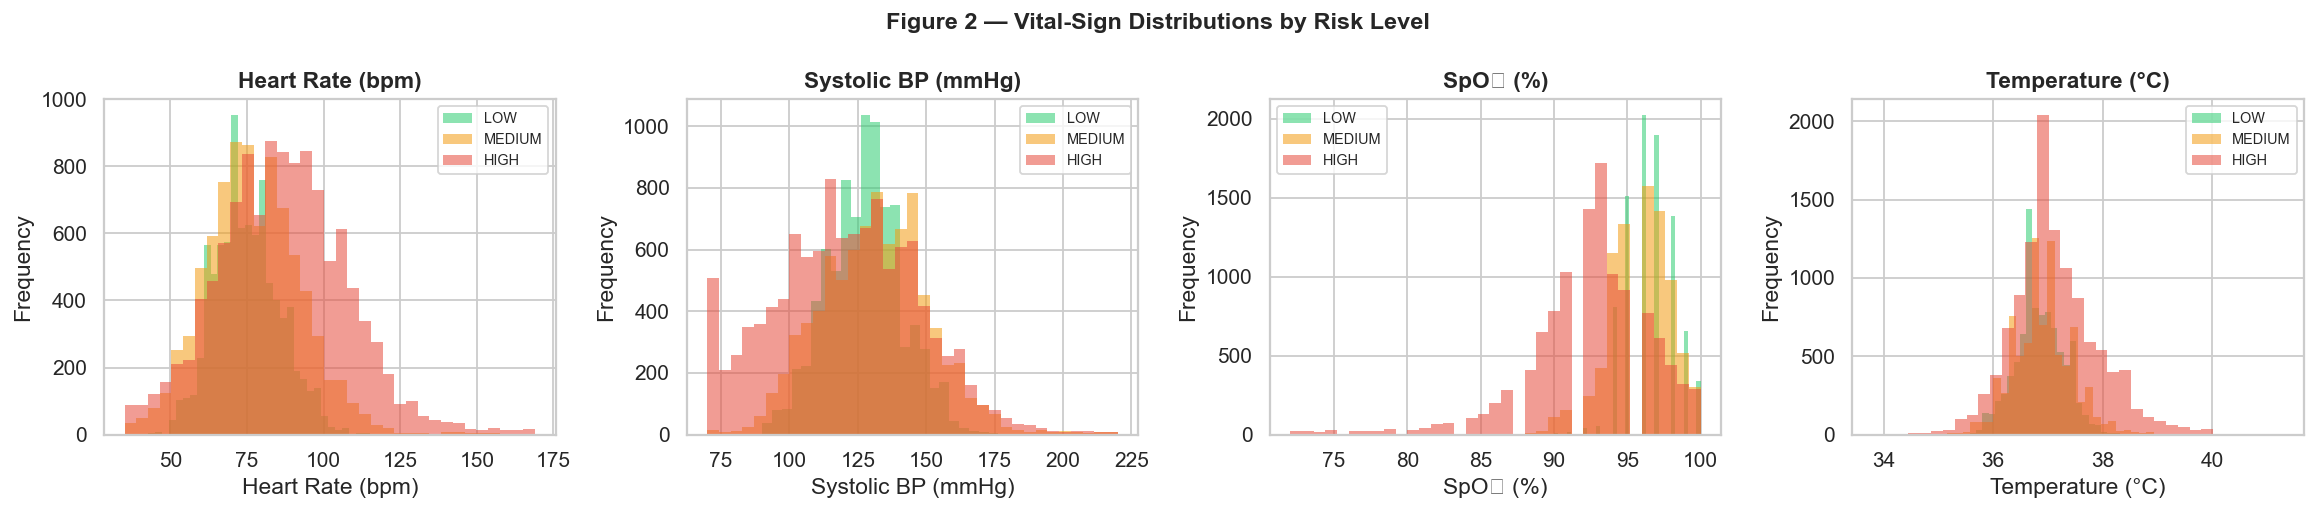

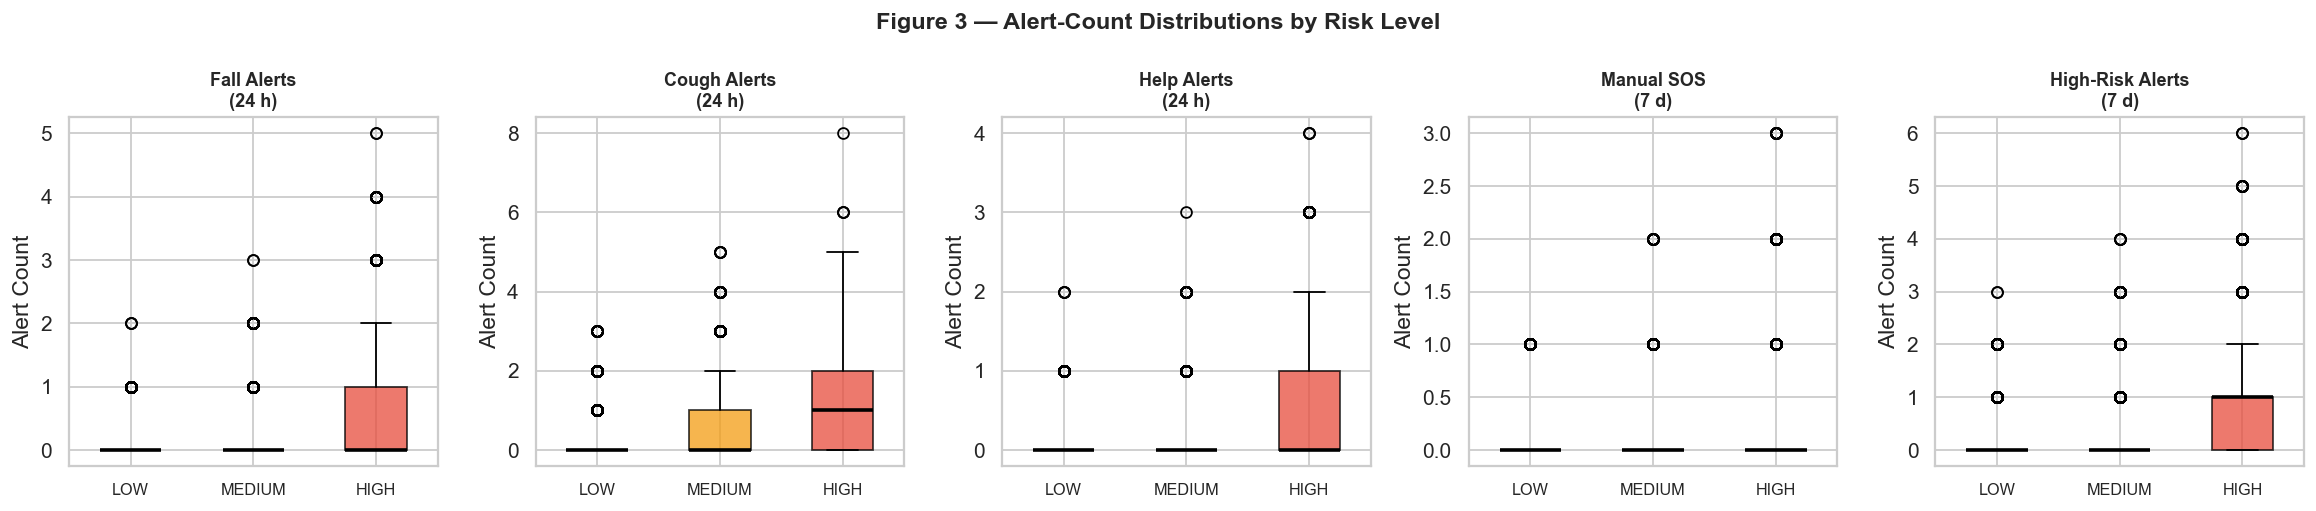

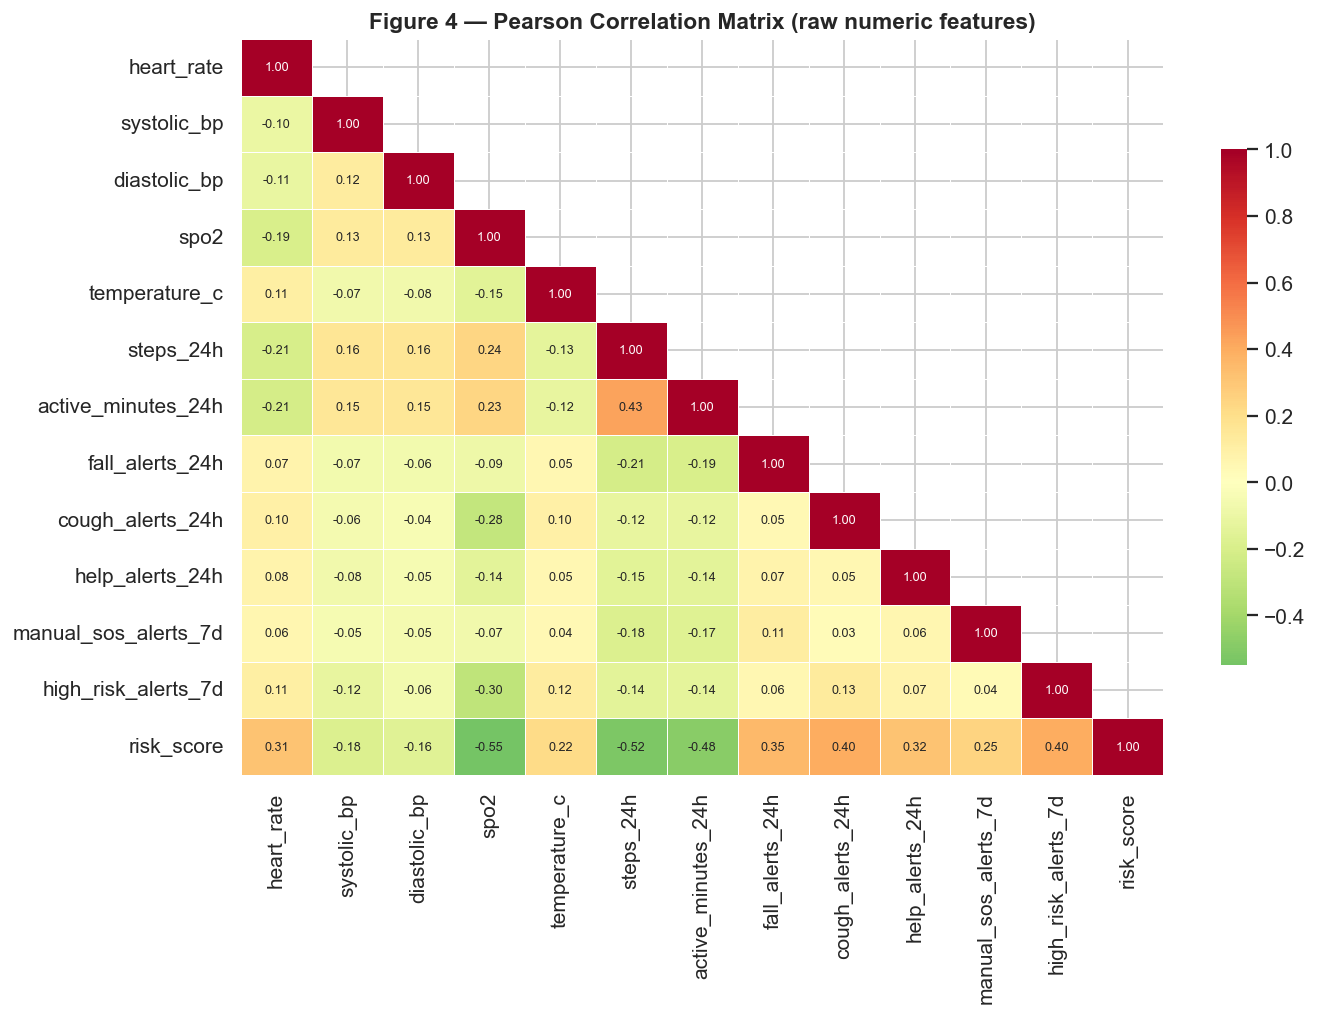

In [3]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 3 — Exploratory Data Analysis
# Purpose : Understand the raw dataset's structure, distributions, and class
#           balance before any feature engineering or modelling.
# ──────────────────────────────────────────────────────────────────────────────

CLASS_ORDER = ["LOW", "MEDIUM", "HIGH"]

# ── 3a. Class distribution bar chart ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count bar
counts = df["risk_level"].value_counts().reindex(CLASS_ORDER)
axes[0].bar(counts.index, counts.values,
            color=[PALETTE[c] for c in counts.index], edgecolor="white", width=0.55)
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 150, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Class Distribution — Count", fontweight="bold")
axes[0].set_xlabel("Risk Level")
axes[0].set_ylabel("Patient Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))

# Pie chart
axes[1].pie(
    counts.values,
    labels=counts.index,
    colors=[PALETTE[c] for c in counts.index],
    autopct="%1.1f%%",
    startangle=140,
    wedgeprops=dict(edgecolor="white", linewidth=1.5),
)
axes[1].set_title("Class Distribution — Proportion", fontweight="bold")

plt.suptitle("Figure 1 — Risk Level Class Balance", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── 3b. Vital-sign distributions by risk level ────────────────────────────────
vitals = ["heart_rate", "systolic_bp", "spo2", "temperature_c"]
vital_labels = ["Heart Rate (bpm)", "Systolic BP (mmHg)", "SpO₂ (%)", "Temperature (°C)"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, col, label in zip(axes, vitals, vital_labels):
    for lvl in CLASS_ORDER:
        subset = df.loc[df["risk_level"] == lvl, col]
        ax.hist(subset, bins=35, alpha=0.55, color=PALETTE[lvl], label=lvl, edgecolor="none")
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Frequency")
    ax.legend(fontsize=8)

plt.suptitle("Figure 2 — Vital-Sign Distributions by Risk Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3c. Alert-count box plots by risk level ───────────────────────────────────
alert_cols = [
    "fall_alerts_24h", "cough_alerts_24h",
    "help_alerts_24h", "manual_sos_alerts_7d", "high_risk_alerts_7d",
]
alert_labels = [
    "Fall Alerts\n(24 h)", "Cough Alerts\n(24 h)",
    "Help Alerts\n(24 h)", "Manual SOS\n(7 d)", "High-Risk Alerts\n(7 d)",
]

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for ax, col, label in zip(axes, alert_cols, alert_labels):
    data_by_class = [df.loc[df["risk_level"] == lvl, col].values for lvl in CLASS_ORDER]
    bp = ax.boxplot(data_by_class, patch_artist=True, widths=0.5,
                    medianprops=dict(color="black", linewidth=2))
    for patch, lvl in zip(bp["boxes"], CLASS_ORDER):
        patch.set_facecolor(PALETTE[lvl])
        patch.set_alpha(0.75)
    ax.set_xticklabels(CLASS_ORDER, fontsize=9)
    ax.set_title(label, fontweight="bold", fontsize=10)
    ax.set_ylabel("Alert Count")

plt.suptitle("Figure 3 — Alert-Count Distributions by Risk Level", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 3d. Correlation heatmap of numeric raw features ──────────────────────────
numeric_raw = [
    "heart_rate", "systolic_bp", "diastolic_bp", "spo2", "temperature_c",
    "steps_24h", "active_minutes_24h", "fall_alerts_24h", "cough_alerts_24h",
    "help_alerts_24h", "manual_sos_alerts_7d", "high_risk_alerts_7d", "risk_score",
]
corr = df[numeric_raw].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)  # show lower triangle
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f", cmap="RdYlGn_r",
    center=0, linewidths=0.4, ax=ax, annot_kws={"size": 7},
    cbar_kws={"shrink": 0.7},
)
ax.set_title("Figure 4 — Pearson Correlation Matrix (raw numeric features)", fontweight="bold")
plt.tight_layout()
plt.show()


## 🔧 4. Feature Engineering

This section constructs the **35 engineered features** the model will train on.

Features fall into six groups:

| Group | Examples |
|---|---|
| Haemodynamic indices | pulse pressure, MAP, shock index |
| Binary clinical flags | fever_flag, hypoxia_flag, hypotension_flag |
| Text-encoding counts | history_condition_count, note_issue_count |
| Event-burden aggregates | event_burden_24h, weighted_event_burden |
| **Cross-modal interactions** | cough×hypoxia, fall×hypotension, SOS×fall |
| Physiological instability index | linear combination of shock index + deficits + flags |

In [4]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 4 — Feature Engineering
# Purpose : Transform raw multimodal inputs into a rich feature set that
#           explicitly represents cross-modal interactions, derived clinical
#           indices, and aggregated event burdens.
# ──────────────────────────────────────────────────────────────────────────────

def count_matches(text: str, terms: list[str]) -> int:
    """Count how many *terms* appear in *text* (case-insensitive substring match)."""
    text = str(text).lower()
    return sum(1 for term in terms if term in text)


def build_multimodal_features(frame: pd.DataFrame) -> pd.DataFrame:
    """
    Augment *frame* with all engineered features.

    Returns a new DataFrame; the original is not modified.

    Feature Groups
    ──────────────
    1. Haemodynamic indices    : pulse_pressure, map_estimate, shock_index
    2. Clinical binary flags   : fever_flag, hypoxia_flag, hypotension_flag, …
    3. SpO₂ deficit            : continuous measure of hypoxia severity
    4. Text-encoded counts     : history_condition_count, note_issue_count
    5. Event-burden aggregates : event_burden_24h, event_burden_7d, weighted_event_burden
    6. Cross-modal interactions: cough×hypoxia, fall×hypotension, SOS×fall, …
    7. Instability index       : linear combination capturing physiological deterioration
    """
    out = frame.copy()

    # ── Group 1: Haemodynamic indices ─────────────────────────────────────────
    # Pulse pressure < 25 mmHg is associated with reduced cardiac output
    out["pulse_pressure"] = out["systolic_bp"] - out["diastolic_bp"]

    # Mean Arterial Pressure — perfusion adequacy indicator
    out["map_estimate"]   = (out["systolic_bp"] + 2 * out["diastolic_bp"]) / 3.0

    # Shock Index (HR / SBP): ≥ 1.0 is a clinical red flag for haemodynamic instability
    out["shock_index"]    = out["heart_rate"] / out["systolic_bp"].clip(lower=1)

    # ── Group 2: Clinical binary flags ────────────────────────────────────────
    out["spo2_deficit"]            = (100 - out["spo2"]).clip(lower=0)   # continuous
    out["fever_flag"]              = (out["temperature_c"] >= 38.0).astype(int)
    out["hypoxia_flag"]            = (out["spo2"] < 94).astype(int)
    out["severe_hypoxia_flag"]     = (out["spo2"] < 90).astype(int)
    out["tachycardia_flag"]        = (out["heart_rate"] > 100).astype(int)
    out["hypotension_flag"]        = (out["systolic_bp"] < 90).astype(int)
    out["low_steps_flag"]          = (out["steps_24h"] < 1000).astype(int)
    out["low_activity_minutes_flag"] = (out["active_minutes_24h"] < 15).astype(int)

    # ── Group 3: Text-encoded feature counts ──────────────────────────────────
    # Converts unstructured text fields into ordinal counts for the model
    out["history_condition_count"] = out["history"].apply(
        lambda v: count_matches(v, HISTORY_TERMS)
    )
    out["note_issue_count"] = out["notes"].apply(
        lambda v: count_matches(v, NOTE_TERMS)
    )

    # ── Group 4: Event-burden aggregates ──────────────────────────────────────
    # Raw count aggregates
    out["event_burden_24h"] = (
        out["fall_alerts_24h"] + out["cough_alerts_24h"] + out["help_alerts_24h"]
    )
    out["event_burden_7d"]  = out["manual_sos_alerts_7d"] + out["high_risk_alerts_7d"]

    # Weighted aggregate — falls and help requests carry more clinical weight
    out["weighted_event_burden"] = (
        2.5 * out["fall_alerts_24h"]
        + 1.5 * out["cough_alerts_24h"]
        + 2.0 * out["help_alerts_24h"]
        + 2.2 * out["manual_sos_alerts_7d"]
        + 1.8 * out["high_risk_alerts_7d"]
    )

    # ── Group 5: Cross-modal interaction features (key novelty) ───────────────
    # Each interaction captures synergistic risk not present in either feature alone.
    out["cough_hypoxia_interaction"]    = out["cough_alerts_24h"] * out["hypoxia_flag"]
    out["cough_fever_interaction"]      = out["cough_alerts_24h"] * out["fever_flag"]
    out["fall_hypotension_interaction"] = out["fall_alerts_24h"]  * out["hypotension_flag"]
    out["fall_low_mobility_interaction"]= out["fall_alerts_24h"]  * out["low_steps_flag"]
    out["help_recurrence_interaction"]  = out["help_alerts_24h"]  * out["high_risk_alerts_7d"]
    out["sos_fall_interaction"]         = out["manual_sos_alerts_7d"] * out["fall_alerts_24h"]

    # ── Group 6: Composite physiological instability index ───────────────────
    # Higher values indicate greater combined haemodynamic / respiratory instability
    out["instability_index"] = (
        1.2 * out["shock_index"]
        + 0.8 * out["spo2_deficit"]
        + 5.0 * out["fever_flag"]
        + 3.0 * out["tachycardia_flag"]
        + 4.0 * out["hypotension_flag"]
    )

    return out


# ── Apply feature engineering ─────────────────────────────────────────────────
feature_df = build_multimodal_features(df)
feature_df.to_csv(FEATURE_EXPORT_PATH, index=False)

print(f"✅ Feature engineering complete — {feature_df.shape[1]} total columns")
print(f"   Engineered features exported to: {FEATURE_EXPORT_PATH}")
display(feature_df.head(3))

# ── Quick descriptive statistics of key engineered features ───────────────────
eng_cols = [
    "pulse_pressure", "shock_index", "spo2_deficit", "instability_index",
    "weighted_event_burden", "history_condition_count", "note_issue_count",
]
print("\nEngineered feature summary statistics:")
display(feature_df[eng_cols].describe().round(3))


✅ Feature engineering complete — 44 total columns
   Engineered features exported to: G:\care-companion-ai-main\models\risk\multimodal_risk_feature_sample.csv


,patient_id,age_group,gender,profile,heart_rate,systolic_bp,diastolic_bp,spo2,temperature_c,activity_level,...,event_burden_24h,event_burden_7d,weighted_event_burden,cough_hypoxia_interaction,cough_fever_interaction,fall_hypotension_interaction,fall_low_mobility_interaction,help_recurrence_interaction,sos_fall_interaction,instability_index
0,P00245,65-74,F,cardiac_patient,86.0,125.0,60.0,96.0,NaN,low,...,1,0,1.5,0,0,0,0,0,0,4.0256
1,P03955,75-84,M,healthy_senior,76.0,128.0,87.0,99.0,36.9,active,...,1,1,3.8,0,0,0,0,1,0,1.5125
2,P02755,75-84,F,moderate_frailty,114.0,114.0,46.0,100.0,36.5,bed_bound,...,1,0,2.5,0,0,0,1,0,0,4.2000



Engineered feature summary statistics:


,pulse_pressure,shock_index,spo2_deficit,instability_index,weighted_event_burden,history_condition_count,note_issue_count
count,27068.000,27049.000,28515.000,25711.000,30000.000,30000.000,30000.000
mean,49.574,0.663,5.389,6.024,2.778,1.414,0.839
std,23.936,0.217,3.651,4.070,2.806,1.293,0.884
min,-55.000,0.187,0.000,0.257,0.000,0.000,0.000
25%,34.000,0.520,3.000,3.172,0.000,0.000,0.000
50%,50.000,0.618,5.000,4.788,2.000,1.000,1.000
75%,65.000,0.755,7.000,7.677,4.300,2.000,1.000
max,163.000,2.100,28.000,32.595,23.400,6.000,4.000


## 🏋️ 5. Model Training

### Architecture — Soft-Voting Ensemble

The classifier is a **soft-voting ensemble** of two diverse tree-based models:

| Component | Rationale |
|---|---|
| `RandomForestClassifier (500 trees)` | Bagging-based; low variance, strong baselines on tabular data |
| `ExtraTreesClassifier (550 trees)` | Extra randomisation in split selection; complements RF on high-dimensional feature sets |
| Soft voting | Averages probability estimates rather than counting votes → smoother decision boundaries |

Both base learners use `class_weight="balanced"` / `"balanced_subsample"` to handle any class imbalance.

### Preprocessing Pipeline

```
ColumnTransformer
 ├── numeric  → SimpleImputer(median) → StandardScaler
 └── categorical → SimpleImputer(mode) → OneHotEncoder(handle_unknown='ignore')
```

The full pipeline (preprocessor + classifier) is fitted on the training fold only, preventing data leakage.

In [5]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 5 — Model Training
# Purpose : Define the preprocessing pipeline, ensemble architecture, and fit
#           on the 80 % training split. Cross-validation is also performed to
#           provide an unbiased generalisation estimate.
# ──────────────────────────────────────────────────────────────────────────────

TARGET_COL = "risk_level"

# ── Feature column lists ──────────────────────────────────────────────────────
# Numeric features: raw vitals + engineered clinical indices + interaction terms
NUMERIC_FEATURES = [
    # Raw vitals
    "heart_rate", "systolic_bp", "diastolic_bp", "spo2", "temperature_c",
    # Functional
    "steps_24h", "active_minutes_24h",
    # Alert counts
    "fall_alerts_24h", "cough_alerts_24h", "help_alerts_24h",
    "manual_sos_alerts_7d", "high_risk_alerts_7d",
    # Haemodynamic indices
    "pulse_pressure", "map_estimate", "shock_index", "spo2_deficit",
    # Binary clinical flags
    "fever_flag", "hypoxia_flag", "severe_hypoxia_flag",
    "tachycardia_flag", "hypotension_flag",
    "low_steps_flag", "low_activity_minutes_flag",
    # Text-encoded counts
    "history_condition_count", "note_issue_count",
    # Event-burden aggregates
    "event_burden_24h", "event_burden_7d", "weighted_event_burden",
    # Cross-modal interaction features (key novelty)
    "cough_hypoxia_interaction", "cough_fever_interaction",
    "fall_hypotension_interaction", "fall_low_mobility_interaction",
    "help_recurrence_interaction", "sos_fall_interaction",
    # Composite index
    "instability_index",
]

# Categorical features: one-hot encoded in the pipeline
CATEGORICAL_FEATURES = ["activity_level"]

# ── Train / test split ────────────────────────────────────────────────────────
X = feature_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = feature_df[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=y,         # preserve class proportions in both splits
)

print(f"Train set : {X_train.shape[0]:,} samples")
print(f"Test set  : {X_test.shape[0]:,} samples")
print(f"Features  : {X_train.shape[1]}")
print()

# ── Preprocessing pipeline ────────────────────────────────────────────────────
numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),   # robust to skewed vitals
    ("scaler",  StandardScaler()),                   # required for shock_index, map_estimate
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot",  OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe,      NUMERIC_FEATURES),
        ("cat", categorical_pipe,  CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

# ── Base learners ─────────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=18,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced_subsample",  # rebalance per bootstrap sample
)

et = ExtraTreesClassifier(
    n_estimators=550,
    max_depth=20,
    min_samples_leaf=2,
    random_state=SEED,
    n_jobs=-1,
    class_weight="balanced",
)

# ── Soft-voting ensemble ──────────────────────────────────────────────────────
fusion_clf = VotingClassifier(
    estimators=[("rf", rf), ("et", et)],
    voting="soft",   # average predicted probabilities → smoother decision surface
    n_jobs=-1,
)

# ── Full pipeline ─────────────────────────────────────────────────────────────
model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier",   fusion_clf),
])

# ── Cross-validation (stratified k-fold) ─────────────────────────────────────
# Run CV on the training data only to avoid leakage from the held-out test set.
print(f"Running {CV_FOLDS}-fold stratified cross-validation on training split …")
cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
print(f"CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print(f"  Per-fold : {[round(s, 4) for s in cv_scores]}")
print()

# ── Final fit on full training split ─────────────────────────────────────────
print("Fitting final model on full training split …")
model.fit(X_train, y_train)
print("✅ Training complete.")


Train set : 24,000 samples
Test set  : 6,000 samples
Features  : 36

Running 5-fold stratified cross-validation on training split …
CV Accuracy: 0.8358 ± 0.0045
  Per-fold : [np.float64(0.8323), np.float64(0.84), np.float64(0.8344), np.float64(0.8302), np.float64(0.8421)]

Fitting final model on full training split …
✅ Training complete.


## 📊 6. Evaluation & Visualisation

We evaluate the trained model on the **held-out 20 % test set** using:
- Overall accuracy and per-class metrics (precision, recall, F1)
- Confusion matrix with row-normalised proportions
- One-vs-Rest ROC curves (AUC per class)
- Precision–Recall curves (more informative than ROC for class-imbalanced settings)
- Feature importance (mean decrease in impurity, averaged across RF and ET)

Test Accuracy : 0.8300  (83.00 %)

Classification Report:
────────────────────────────────────────────────────────────
              precision    recall  f1-score   support

         LOW     0.9237    0.8944    0.9088      2395
      MEDIUM     0.8345    0.8467    0.8406      1840
        HIGH     0.7056    0.7252    0.7153      1765

    accuracy                         0.8300      6000
   macro avg     0.8213    0.8221    0.8215      6000
weighted avg     0.8322    0.8300    0.8309      6000



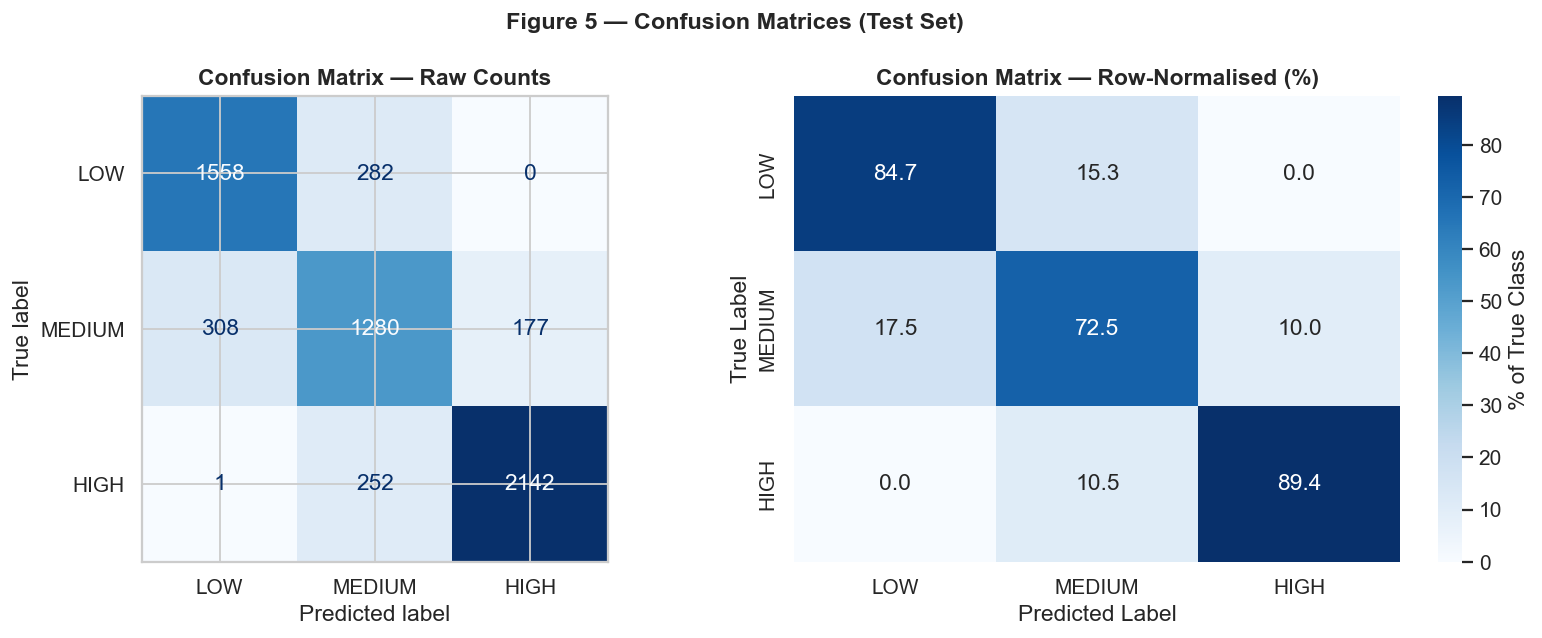

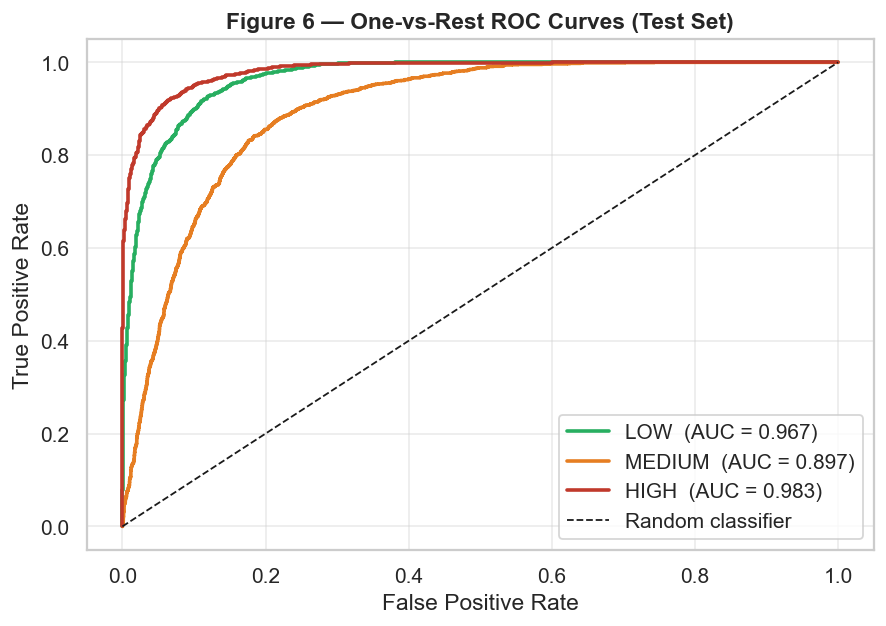

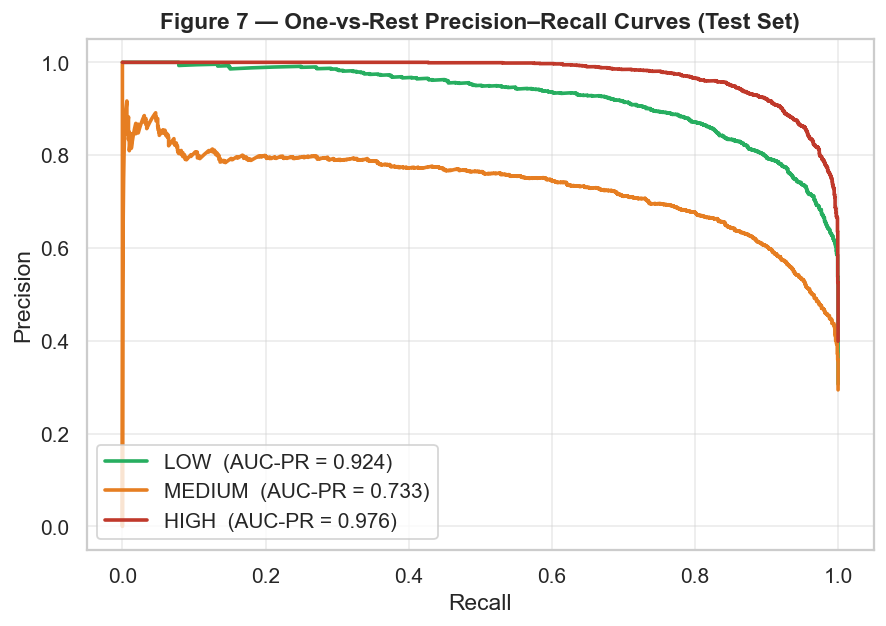

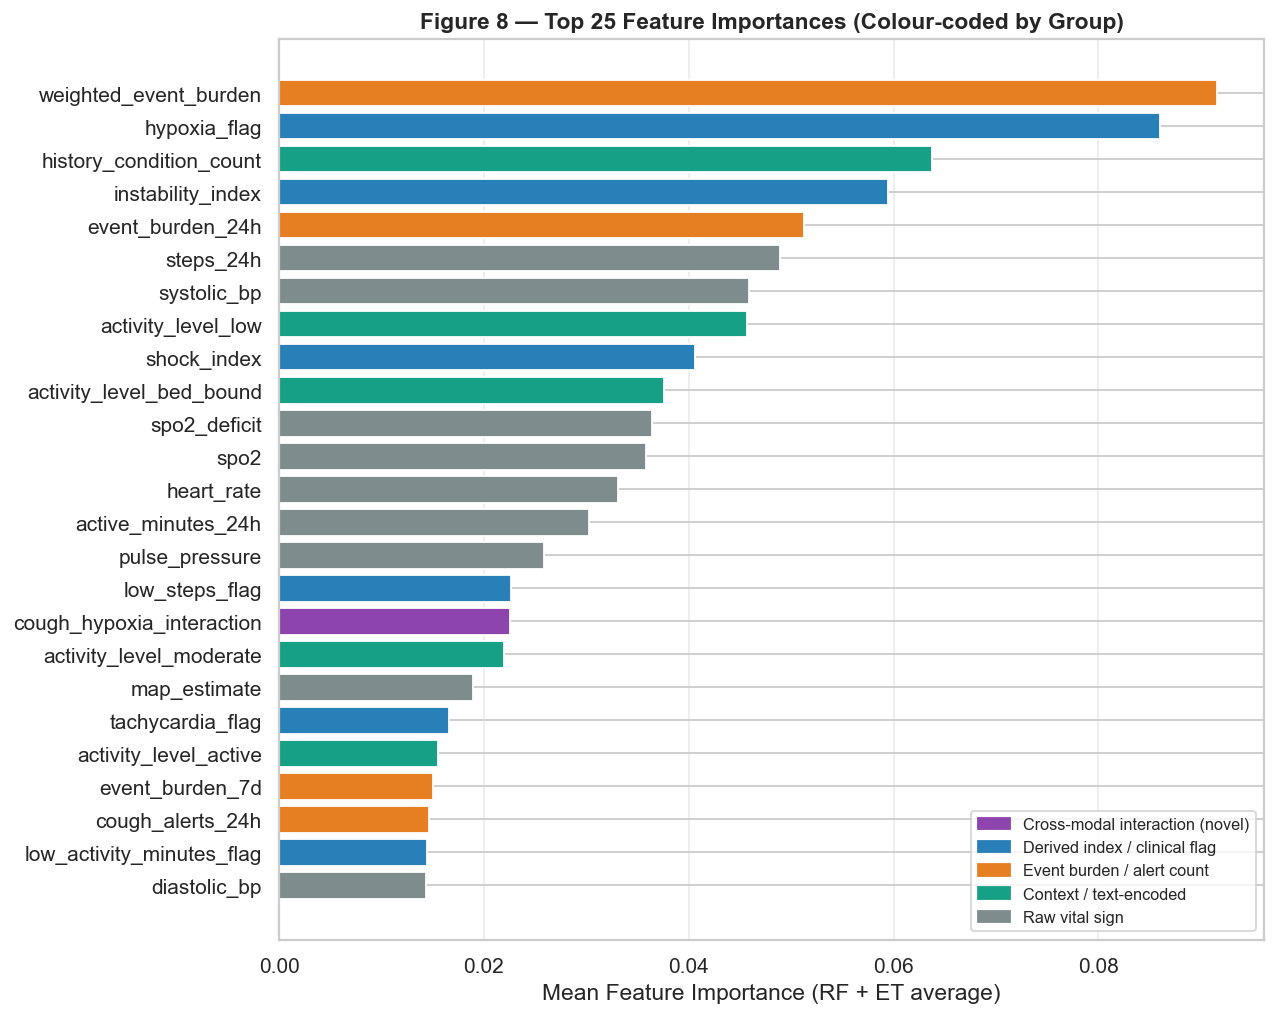


Per-Class Metrics Summary:


,Class,Precision,Recall,F1-Score
0,LOW,0.8345,0.8467,0.8406
1,MEDIUM,0.7056,0.7252,0.7153
2,HIGH,0.9237,0.8944,0.9088



Overall Test Accuracy : 0.8300
CV Accuracy (mean±std) : 0.8358 ± 0.0045


In [6]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 6 — Evaluation & Visualisation
# Purpose : Quantify and visualise model performance on the held-out test set.
#           All figures are formatted for inclusion in a major-project report.
# ──────────────────────────────────────────────────────────────────────────────

CLASS_ORDER = ["LOW", "MEDIUM", "HIGH"]

# ── Predictions ───────────────────────────────────────────────────────────────
y_pred      = model.predict(X_test)
y_proba     = model.predict_proba(X_test)          # shape (n_samples, 3)
class_names = model.named_steps["classifier"].classes_  # order from sklearn

accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy : {accuracy:.4f}  ({accuracy*100:.2f} %)")
print()
print("Classification Report:")
print("─" * 60)
print(classification_report(y_test, y_pred, target_names=CLASS_ORDER, digits=4))

# ── 6a. Confusion matrix ──────────────────────────────────────────────────────
cm     = confusion_matrix(y_test, y_pred, labels=CLASS_ORDER)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100   # row-normalised %

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_ORDER)
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title("Confusion Matrix — Raw Counts", fontweight="bold")

# Row-normalised percentages
sns.heatmap(
    cm_pct, annot=True, fmt=".1f", cmap="Blues",
    xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER,
    ax=axes[1], cbar_kws={"label": "% of True Class"},
)
axes[1].set_title("Confusion Matrix — Row-Normalised (%)", fontweight="bold")
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("True Label")

plt.suptitle("Figure 5 — Confusion Matrices (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# ── 6b. ROC curves (One-vs-Rest) ──────────────────────────────────────────────
y_bin = label_binarize(y_test, classes=CLASS_ORDER)   # (n, 3) binary matrix
# Reorder proba columns to match CLASS_ORDER
proba_ordered = np.column_stack([
    y_proba[:, list(class_names).index(cls)] for cls in CLASS_ORDER
])

fig, ax = plt.subplots(figsize=(7, 5))
roc_colors = {"LOW": "#27ae60", "MEDIUM": "#e67e22", "HIGH": "#c0392b"}
for i, cls in enumerate(CLASS_ORDER):
    fpr, tpr, _ = roc_curve(y_bin[:, i], proba_ordered[:, i])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, lw=2, color=roc_colors[cls], label=f"{cls}  (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random classifier")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 6 — One-vs-Rest ROC Curves (Test Set)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# ── 6c. Precision–Recall curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
for i, cls in enumerate(CLASS_ORDER):
    prec, rec, _ = precision_recall_curve(y_bin[:, i], proba_ordered[:, i])
    pr_auc = auc(rec, prec)
    ax.plot(rec, prec, lw=2, color=roc_colors[cls], label=f"{cls}  (AUC-PR = {pr_auc:.3f})")

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Figure 7 — One-vs-Rest Precision–Recall Curves (Test Set)", fontweight="bold")
ax.legend(loc="lower left")
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.show()

# ── 6d. Feature Importance (averaged RF + ET) ─────────────────────────────────
# Extract the two fitted base estimators from the VotingClassifier inside the Pipeline
voting_clf = model.named_steps["classifier"]
fitted_rf  = voting_clf.estimators_[0]   # RandomForest
fitted_et  = voting_clf.estimators_[1]   # ExtraTrees

# Combine importances (simple average of normalised importances)
imp_rf = fitted_rf.feature_importances_
imp_et = fitted_et.feature_importances_
avg_imp = (imp_rf + imp_et) / 2.0

# Reconstruct feature names after preprocessing
cat_encoder  = model.named_steps["preprocessor"].named_transformers_["cat"]["onehot"]
cat_names    = list(cat_encoder.get_feature_names_out(CATEGORICAL_FEATURES))
all_feat_names = NUMERIC_FEATURES + cat_names

imp_df = (
    pd.DataFrame({"feature": all_feat_names, "importance": avg_imp})
    .sort_values("importance", ascending=False)
    .head(25)     # top 25 features for clarity
    .reset_index(drop=True)
)

# Colour bars by feature group
def feature_colour(name: str) -> str:
    if "interaction" in name:
        return "#8e44ad"   # purple = interaction features (novel)
    if "flag" in name or "index" in name or "shock" in name:
        return "#2980b9"   # blue = derived indices / flags
    if "burden" in name or "alerts" in name or "sos" in name:
        return "#e67e22"   # orange = event burden
    if "history" in name or "note" in name or "activity" in name:
        return "#16a085"   # teal = context / text
    return "#7f8c8d"       # grey = raw vitals

bar_colours = [feature_colour(n) for n in imp_df["feature"]]

fig, ax = plt.subplots(figsize=(10, 8))
bars = ax.barh(imp_df["feature"][::-1], imp_df["importance"][::-1],
               color=bar_colours[::-1], edgecolor="white")
ax.set_xlabel("Mean Feature Importance (RF + ET average)")
ax.set_title("Figure 8 — Top 25 Feature Importances (Colour-coded by Group)", fontweight="bold")

# Legend
from matplotlib.patches import Patch
legend_handles = [
    Patch(color="#8e44ad", label="Cross-modal interaction (novel)"),
    Patch(color="#2980b9", label="Derived index / clinical flag"),
    Patch(color="#e67e22", label="Event burden / alert count"),
    Patch(color="#16a085", label="Context / text-encoded"),
    Patch(color="#7f8c8d", label="Raw vital sign"),
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=9)
ax.grid(axis="x", alpha=0.35)
plt.tight_layout()
plt.show()

# ── 6e. Summary metrics table ─────────────────────────────────────────────────
from sklearn.metrics import precision_score, recall_score, f1_score
metrics_df = pd.DataFrame({
    "Class":     CLASS_ORDER,
    "Precision": [precision_score(y_test, y_pred, labels=[c], average="macro",
                                   zero_division=0) for c in CLASS_ORDER],
    "Recall":    [recall_score(y_test, y_pred, labels=[c], average="macro",
                                zero_division=0) for c in CLASS_ORDER],
    "F1-Score":  [f1_score(y_test, y_pred, labels=[c], average="macro",
                            zero_division=0) for c in CLASS_ORDER],
}).round(4)

print("\nPer-Class Metrics Summary:")
display(metrics_df)
print(f"\nOverall Test Accuracy : {accuracy:.4f}")
print(f"CV Accuracy (mean±std) : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


## 💾 7. Model Serialisation

The trained pipeline (preprocessor + ensemble classifier) is serialised with `joblib` alongside metadata for reproducibility.

In [7]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 7 — Model Serialisation
# Purpose : Persist the full sklearn Pipeline so it can be loaded directly at
#           inference time without re-running any preprocessing code.
# ──────────────────────────────────────────────────────────────────────────────

model_bundle = {
    "model":               model,
    "numeric_features":    NUMERIC_FEATURES,
    "categorical_features": CATEGORICAL_FEATURES,
    "target":              TARGET_COL,
    "class_order":         CLASS_ORDER,
    "data_source":         data_source,
    "test_accuracy":       round(accuracy, 4),
    "cv_accuracy_mean":    round(float(cv_scores.mean()), 4),
    "cv_accuracy_std":     round(float(cv_scores.std()), 4),
    "seed":                SEED,
    "novelty":             (
        "Multimodal event-aware fusion of physiological vitals, "
        "sensor-event alert counts, and functional context with "
        "explicit cross-modal interaction features."
    ),
}

joblib.dump(model_bundle, MODEL_PATH)
print(f"✅ Model bundle saved to: {MODEL_PATH}")
print()
print("Bundle keys:")
for k, v in model_bundle.items():
    if k == "model":
        print(f"  model : {type(v).__name__}")
    elif k not in ("numeric_features", "categorical_features"):
        print(f"  {k:<25} : {v}")


✅ Model bundle saved to: G:\care-companion-ai-main\models\risk\novel_multimodal_risk_classifier.joblib

Bundle keys:
  model : Pipeline
  target                    : risk_level
  class_order               : ['LOW', 'MEDIUM', 'HIGH']
  data_source               : real CSV: multimodal_risk_training_data.csv
  test_accuracy             : 0.83
  cv_accuracy_mean          : 0.8358
  cv_accuracy_std           : 0.0045
  seed                      : 42
  novelty                   : Multimodal event-aware fusion of physiological vitals, sensor-event alert counts, and functional context with explicit cross-modal interaction features.


## 🩺 8. Inference Demo — Sample Patient Prediction

Demonstrates end-to-end inference on a high-risk synthetic patient with:
- Severe hypoxia (SpO₂ 89 %)
- Tachycardia (HR 112 bpm) + hypotension (SBP 88 mmHg)
- Fever (38.8 °C)
- Active falls, cough, and help alerts
- History of COPD, diabetes, falls
- Documented confusion and shortness of breath

  SAMPLE PATIENT — RISK ASSESSMENT
  Predicted Risk Level : HIGH

  Class Probabilities:
    HIGH     1.0000  ████████████████████████████████████████
    LOW      0.0000  
    MEDIUM   0.0000  


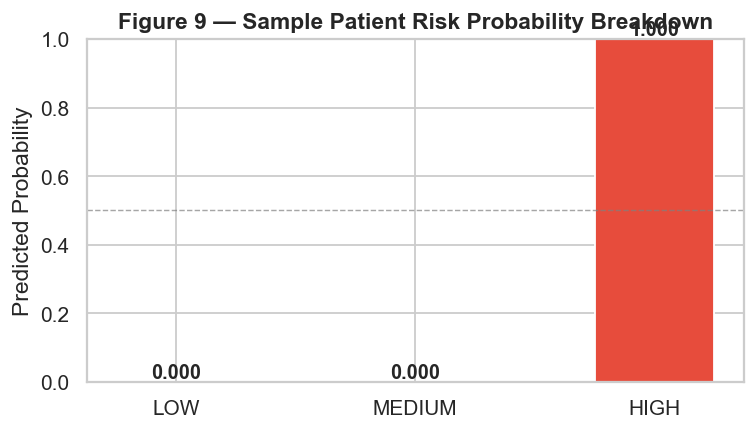


Key derived indices for this patient:
  Shock Index        : 1.273  (≥ 1.0 = haemodynamic red flag)
  SpO₂ Deficit       : 11.0 pp  (100 - SpO₂)
  Instability Index  : 22.33  (composite)


In [8]:
# ──────────────────────────────────────────────────────────────────────────────
# Section 8 — Inference Demo
# Purpose : Show how to load the serialised model and run a prediction on a
#           new patient record, as would be done by the Care Companion backend.
# ──────────────────────────────────────────────────────────────────────────────

# ── Construct a realistic high-risk patient record ────────────────────────────
sample_patient = pd.DataFrame([{
    "heart_rate":           112,   # tachycardia
    "systolic_bp":           88,   # hypotension
    "diastolic_bp":          54,
    "spo2":                  89,   # severe hypoxia
    "temperature_c":         38.8, # fever
    "activity_level":    "bed_bound",
    "steps_24h":            180,
    "active_minutes_24h":     4,
    "fall_alerts_24h":        1,
    "cough_alerts_24h":       3,
    "help_alerts_24h":        1,
    "manual_sos_alerts_7d":   1,
    "high_risk_alerts_7d":    2,
    "history":    "copd, diabetes, history of falls",
    "notes":      "confusion, shortness of breath, recent infection",
}])

# ── Feature engineering (identical pipeline as training) ──────────────────────
sample_features = build_multimodal_features(sample_patient)
X_sample        = sample_features[NUMERIC_FEATURES + CATEGORICAL_FEATURES]

# ── Prediction ────────────────────────────────────────────────────────────────
predicted_class = model.predict(X_sample)[0]
proba_values    = model.predict_proba(X_sample)[0]
labels          = model.named_steps["classifier"].classes_

# ── Display results ───────────────────────────────────────────────────────────
print("=" * 50)
print("  SAMPLE PATIENT — RISK ASSESSMENT")
print("=" * 50)
print(f"  Predicted Risk Level : {predicted_class}")
print()
print("  Class Probabilities:")
for label, score in zip(labels, proba_values):
    bar = "█" * int(score * 40)
    print(f"    {label:<8} {score:.4f}  {bar}")
print("=" * 50)

# ── Probability bar chart ─────────────────────────────────────────────────────
proba_dict = dict(zip(labels, proba_values))
ordered_proba = [proba_dict.get(c, 0.0) for c in CLASS_ORDER]

fig, ax = plt.subplots(figsize=(6, 3.5))
bars = ax.bar(CLASS_ORDER, ordered_proba,
              color=[PALETTE[c] for c in CLASS_ORDER], edgecolor="white", width=0.5)
for bar, val in zip(bars, ordered_proba):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.012,
            f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylim(0, 1.0)
ax.set_ylabel("Predicted Probability")
ax.set_title("Figure 9 — Sample Patient Risk Probability Breakdown", fontweight="bold")
ax.axhline(0.5, color="grey", linestyle="--", linewidth=0.8, alpha=0.7)
plt.tight_layout()
plt.show()

# ── Instability index breakdown ───────────────────────────────────────────────
si  = sample_features["shock_index"].iloc[0]
spo = sample_features["spo2_deficit"].iloc[0]
ins = sample_features["instability_index"].iloc[0]
print(f"\nKey derived indices for this patient:")
print(f"  Shock Index        : {si:.3f}  (≥ 1.0 = haemodynamic red flag)")
print(f"  SpO₂ Deficit       : {spo:.1f} pp  (100 - SpO₂)")
print(f"  Instability Index  : {ins:.2f}  (composite)")


## 📝 9. Conclusions & Future Work

### Contributions

1. **Multimodal fusion** — the model integrates physiological vitals, event-alert counts, and functional activity context into a single decision pipeline, reflecting the architecture of the Care Companion AI system.
2. **Interaction features** — explicit cross-modal terms (e.g., `cough × hypoxia`, `fall × hypotension`) encode clinical knowledge that a naïve feature concatenation would force the model to re-discover from data.
3. **Ensemble robustness** — soft-voting over RF and ET reduces variance and produces calibrated class probabilities suitable for clinical risk stratification.
4. **End-to-end pipeline** — a single `sklearn.Pipeline` object encapsulates preprocessing + inference, making deployment straightforward.

### Limitations

- The synthetic dataset, while clinically motivated, cannot replicate the full complexity of real patient cohorts (comorbidity co-occurrences, temporal dynamics, medication effects).
- Feature importances reflect in-sample impurity reduction; SHAP-based explanations would be preferable for clinical auditing.
- Threshold selection (LOW / MEDIUM / HIGH boundaries) is fixed; a calibrated cost-sensitive threshold optimisation would be appropriate before clinical deployment.

### Future Work

- Replace synthetic data with real Supabase patient exports once available.
- Add SHAP explainability module for per-prediction feature attribution.
- Implement temporal features (trend over 24 h / 7 d) to capture deterioration trajectories.
- Integrate with Care Companion alert pipeline for real-time risk scoring.
- Evaluate with clinical domain experts and assess calibration (Brier score, reliability diagrams).
